# 2. Clusterização de Eventos (GMM)

Esta seção apresenta a aplicação do Modelo de Mistura Gaussiana (GMM) para identificar padrões latentes de comportamento na rede. O objetivo é agrupar as transições detectadas em categorias semânticas com base na correlação multivariada das métricas.

## 2.1 Seleção do Número de Componentes ($K$)

Para determinar o número ideal de clusters, avaliamos o desempenho do modelo variando o parâmetro $K$. A escolha baseia-se no equilíbrio entre o ajuste aos dados e a complexidade do modelo, utilizando critérios de informação estatística:

* **AIC/BIC:** Indicadores que penalizam modelos com excesso de parâmetros. Valores menores sugerem um melhor compromisso entre ajuste e simplicidade do modelo.
* **Log-Likelihood (LL):** Mede quão bem os parâmetros do modelo explicam os dados. Aumentos no LL indicam que o modelo descreve melhor a amostra.
* **Delta_BIC/Delta_LL:** Quantificam o ganho marginal ao adicionar um novo cluster. Delta_BIC negativo indica ganho de qualidade e Delta_LL positivo indica melhor ajuste aos dados.

> **Nota técnica:** A escolha do $K$ final busca evitar a fragmentação excessiva dos dados, priorizando um número de clusters que possua significado físico (ex: separação clara entre Congestionamento e Mudança de Rota).

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import os
import re

# --- Parâmetros do Estudo ---
SCENARIO = "NDT"
METHOD = "vwcd"
REF_METRIC = "rtt_down"
THRESHOLD = 0.95

# Caminho dos relatórios baseado no cenário atual
path = os.path.join("clusters", SCENARIO)

if not os.path.exists(path):
    print(f"Erro: Pasta {path} não encontrada.")
else:
    data = []
    
    # Regex para capturar K do nome do arquivo e os valores dentro do TXT
    # Utiliza as variáveis globais METHOD (vwcd), REF_METRIC (full) e THRESHOLD
    file_pattern = rf"clusters_K(\d+)_features_{METHOD}_{REF_METRIC}_{THRESHOLD}\.txt"    

    for file in os.listdir(path):
        match = re.match(file_pattern, file)
        if match:
            k_val = int(match.group(1))
            full_path = os.path.join(path, file)
            
            with open(full_path, 'r') as f:
                content = f.read()
                
                # Extração via Regex dos valores numéricos
                aic = re.search(r"AIC.*: ([\d\.-]+)", content)
                bic = re.search(r"BIC.*: ([\d\.-]+)", content)
                ll  = re.search(r"Log-Likelihood: ([\d\.-]+)", content)
                events = re.search(r"Total de Eventos: (\d+)", content)
                
                if aic and bic and ll:
                    data.append({
                        'K': k_val,
                        'Log-Likelihood': float(ll.group(1)),
                        'AIC': float(aic.group(1)),
                        'BIC': float(bic.group(1))
                    })

    if not data:
        print("Nenhum relatório encontrado para os parâmetros fornecidos.")
    else:
        # Criar DataFrame e ordenar por K
        df_comp = pd.DataFrame(data).sort_values('K').reset_index(drop=True)
        
        # Calcular a diferença (Delta) entre o K atual e o anterior
        df_comp['Delta_BIC'] = df_comp['BIC'].diff()
        df_comp['Delta_LL']  = df_comp['Log-Likelihood'].diff()

        # Colocar 0 se o Delta for NaN (primeira linha)
        df_comp['Delta_BIC'] = df_comp['Delta_BIC'].fillna(0)
        df_comp['Delta_LL'] = df_comp['Delta_LL'].fillna(0)

        print(f"\nCOMPARAÇÃO DE MODELOS - CENÁRIO: {SCENARIO}")
        print(f"Métrica: {REF_METRIC} | Threshold: {THRESHOLD}")
        print("=" * 85)
        print(df_comp.to_string(index=False))
        print("=" * 85)


COMPARAÇÃO DE MODELOS - CENÁRIO: NDT
Métrica: rtt_down | Threshold: 0.95
 K  Log-Likelihood       AIC       BIC  Delta_BIC  Delta_LL
 2         4159.42  -8236.84  -8040.73       0.00      0.00
 3         5398.96 -10673.92 -10377.36   -2336.63   1239.54
 4         5540.20 -10914.40 -10517.38    -140.02    141.24
 5         5577.27 -10946.54 -10449.07      68.31     37.07
 6         3517.77  -6785.54  -6187.63    4261.44  -2059.50
 7         3535.56  -6779.13  -6080.76     106.87     17.79
 8         5920.01 -11506.01 -10707.20   -4626.44   2384.45
 9         6118.59 -11861.18 -10961.91    -254.71    198.58
10         6165.40 -11912.81 -10913.09      48.82     46.81


## 2.2 Análise dos Parâmetros e Assinaturas dos Clusters

Com base no valor de $K$ selecionado (aquele com os maiores deltas de BIC e LL em relação ao anterior), as propriedades estatísticas de cada componente são analisadas para identificar as "assinaturas" de rede. Esta etapa utiliza as métricas de ajuste global e a distribuição de eventos para validar a coerência do modelo.

### Métricas de Ajuste do Modelo
* **AIC:** {valor}
* **BIC:** {valor}
* **Log-Likelihood:** {valor}

### Caracterização dos Clusters

A interpretação dos resultados fundamenta-se nos indicadores de comportamento e densidade extraídos do GMM:

1. **Assinaturas Médias (Visualização por Heatmap):** O centro de cada cluster (médias na escala original) define o perfil da transição de rede. O mapa de calor facilita a identificação de padrões coordenados, como o aumento simultâneo de latência e queda de vazão, permitindo correlacionar os agrupamentos a fenômenos como congestionamento ou mudanças de rota.
2. **Volumetria e Representatividade:** A contagem e o percentual de eventos em cada cluster revelam a dominância de certos comportamentos. Agrupamentos com alta densidade indicam o estado típico de operação ou falhas recorrentes, enquanto componentes com baixíssima contagem sinalizam eventos atípicos ou instabilidades isoladas pelo modelo.
3. **Fundamentação Multivariada:** Embora a análise priorize a visualização das médias, a separação dos clusters pelo GMM é sustentada pelas matrizes de covariância calculadas internamente. Isso garante que o agrupamento reflita a dependência estatística entre as variáveis, isolando perfis onde as métricas variam de forma sistêmica.

Esta análise permite verificar se o algoritmo foi capaz de distinguir estados de rede estáveis de anomalias severas, transformando as métricas processadas em categorias funcionais de diagnóstico.

RELATÓRIO DE AJUSTE GLOBAL - K=3
---------------------------------------------
AIC (Akaike Information Criterion): -10673.92
BIC (Bayesian Information Criterion): -10377.36
Log-Likelihood: 5398.96
---------------------------------------------


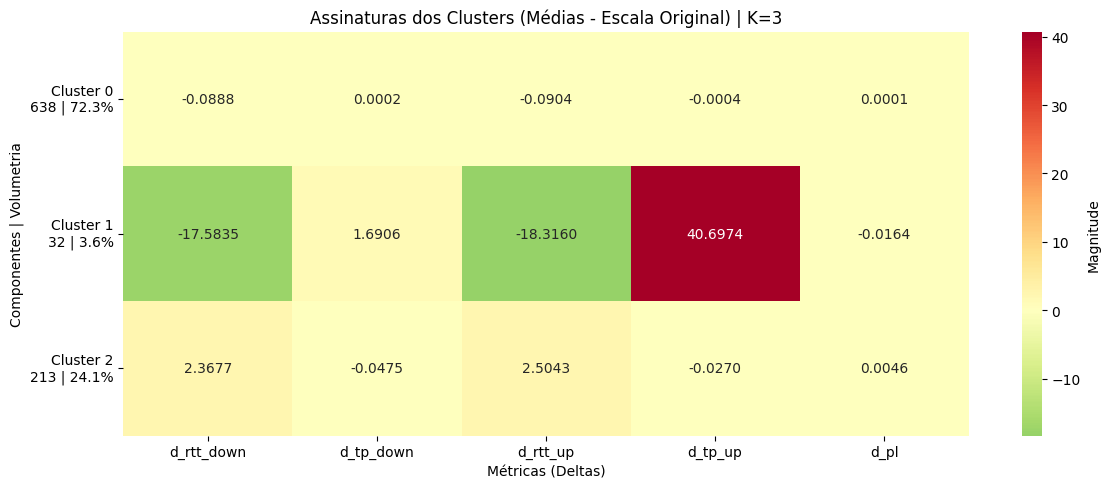


ANÁLISE DE COVARIÂNCIA (ESTRUTURA DE CORRELAÇÃO)
---------------------------------------------


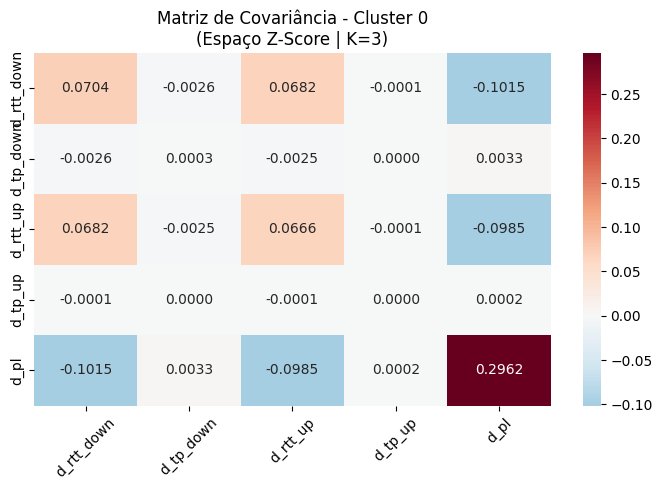

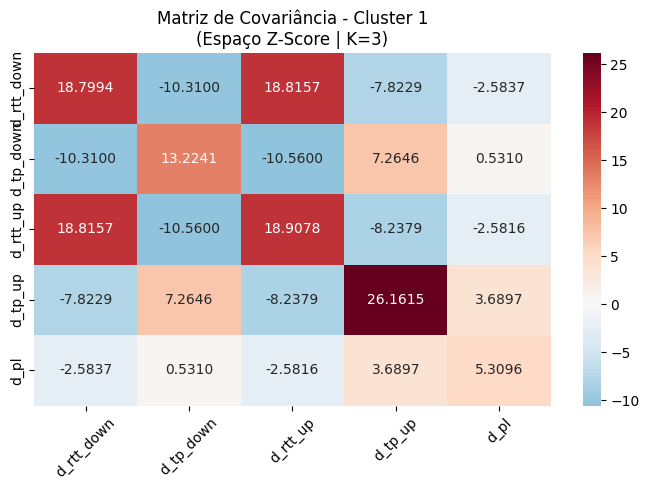

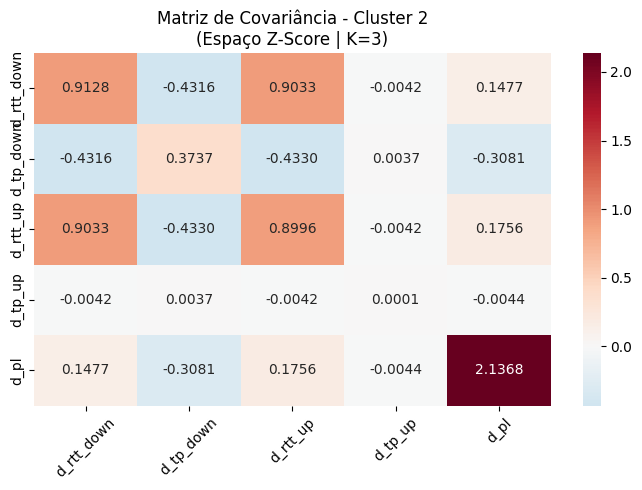

In [16]:
# --- Configuração da Análise ---
K_ANALISE = 3
k_str = str(K_ANALISE).zfill(2)
file_name = f"clusters_K{k_str}_features_{METHOD}_{REF_METRIC}_{THRESHOLD}.txt"
full_path = os.path.join("clusters", SCENARIO, file_name)

if not os.path.exists(full_path):
    print(f"Erro: Arquivo não encontrado em {full_path}")
else:
    with open(full_path, 'r') as f:
        content = f.read()

    # --- 1. RELATÓRIO DE AJUSTE GLOBAL ---
    print(f"RELATÓRIO DE AJUSTE GLOBAL - K={K_ANALISE}")
    print("-" * 45)
    for pattern in [r"AIC.*: ([\d\.-]+)", r"BIC.*: ([\d\.-]+)", r"Log-Likelihood: ([\d\.-]+)"]:
        match = re.search(pattern, content)
        if match:
            print(match.group(0))
    print("-" * 45)

    # --- 2. PROCESSAMENTO DOS CLUSTERS (MÉDIAS E VOLUMETRIA) ---
    cluster_data = []
    volumetry_labels = {}
    cluster_blocks = re.split(r"(Cluster \d+:)", content)
    metrics_list = ['d_rtt_down', 'd_tp_down', 'd_rtt_up', 'd_tp_up', 'd_pl']

    for i in range(1, len(cluster_blocks), 2):
        c_id = cluster_blocks[i].replace(":", "").strip()
        body = cluster_blocks[i+1]
        
        # Extração da Volumetria para os labels do eixo Y
        count_match = re.search(r"Quantidade de Eventos:\s+(\d+)\s+\(([\d\.]+%)\)", body)
        if count_match:
            volumetry_labels[c_id] = f"{c_id}\n{count_match.group(1)} | {count_match.group(2)}"
        
        # Extração das Médias
        means = {}
        for metric in metrics_list:
            m_match = re.search(rf"{metric}:\s+([\d\.-]+)", body)
            if m_match:
                means[metric] = float(m_match.group(1))
        
        if means:
            means['Cluster'] = c_id
            cluster_data.append(means)

    # Plotagem do Heatmap de Médias
    df_heatmap = pd.DataFrame(cluster_data).set_index('Cluster')
    df_heatmap.index = [volumetry_labels.get(idx, idx) for idx in df_heatmap.index]

    plt.figure(figsize=(12, 5))
    sns.heatmap(df_heatmap, annot=True, cmap='RdYlGn_r', center=0, fmt=".4f", cbar_kws={'label': 'Magnitude'})
    plt.title(f"Assinaturas dos Clusters (Médias - Escala Original) | K={K_ANALISE}")
    plt.xlabel("Métricas (Deltas)")
    plt.ylabel("Componentes | Volumetria")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # --- 3. ANÁLISE DE COVARIÂNCIA POR CLUSTER ---
    print("\nANÁLISE DE COVARIÂNCIA (ESTRUTURA DE CORRELAÇÃO)")
    print("-" * 45)
    
    for i in range(1, len(cluster_blocks), 2):
        c_id = cluster_blocks[i].replace(":", "").strip()
        body = cluster_blocks[i+1]

        # Busca a matriz entre [[ e ]]
        matrix_match = re.search(r"Matriz de Covariancia .*?:\n\s*\[\[(.*?)\]\]", body, re.DOTALL)

        if matrix_match:
            matrix_str = matrix_match.group(1)
            clean_rows = []
            for row in matrix_str.split('\n'):
                row_stripped = row.replace('[', '').replace(']', '').strip()
                if row_stripped:
                    clean_rows.append([float(val) for val in row_stripped.split()])

            cov_matrix = np.array(clean_rows)

            # Plotagem do Heatmap da Matriz de Covariância
            plt.figure(figsize=(7, 5))
            sns.heatmap(cov_matrix, annot=True, fmt=".4f", cmap='RdBu_r', center=0,
                        xticklabels=metrics_list, yticklabels=metrics_list)
            
            plt.title(f"Matriz de Covariância - {c_id}\n(Espaço Z-Score | K={K_ANALISE})")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()